In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = "E:/Documents/dtms69/filtered_data_nov.csv"

In [3]:
df = pd.read_csv(path, index_col=None)

In [4]:
df

,PEA_No,DATE_Time,KWH,SelfRead_KWH,VA,VB,VC,AA,AB,AC,KVARH_DEL,KVARH_REC,KWHExport,SelfRead_KWHEXP
0,6200022544,2025-11-01 00:00:00,0.009,0.000,231.0,NaN,NaN,0.0,NaN,NaN,0.000,0.001,0.0,0.000
1,6200022544,2025-11-01 00:15:00,0.008,0.000,230.0,NaN,NaN,0.0,NaN,NaN,0.000,0.000,0.0,0.000
2,6200030933,2025-11-01 00:00:00,0.135,21949.727,232.0,NaN,NaN,2.0,NaN,NaN,0.023,0.000,0.0,0.000
3,6200030933,2025-11-01 00:15:00,0.170,0.000,231.0,NaN,NaN,3.0,NaN,NaN,0.021,0.000,0.0,0.000
4,6200031047,2025-11-01 00:00:00,0.334,32640.742,230.0,NaN,NaN,6.0,NaN,NaN,0.000,0.015,0.0,3442.508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57595,6200061392,2025-11-30 23:30:00,0.794,0.000,235.0,235.0,236.0,12.0,0.0,2.0,0.193,0.000,0.0,0.000
57596,6200061392,2025-11-30 23:45:00,0.764,0.000,234.0,235.0,236.0,11.0,0.0,2.0,0.147,0.000,0.0,0.000
57597,6200118626,2025-11-30 23:15:00,0.001,0.000,236.0,NaN,NaN,0.0,NaN,NaN,0.000,0.002,0.0,0.000
57598,6200118626,2025-11-30 23:30:00,0.001,0.000,236.0,NaN,NaN,0.0,NaN,NaN,0.000,0.001,0.0,0.000


In [42]:
df2 = df.copy()

In [43]:
df2.insert(df2.columns.get_loc('KWH') + 1, 'kW average', df2['KWH'] * 4)

In [44]:
df2.insert(df2.columns.get_loc('KWHExport') + 1, 'kW exp average', df2['KWHExport'] * 4)

In [45]:
df2 = df2.drop(columns=['VA', 'VB', 'VC', 'SelfRead_KWH', 'SelfRead_KWHEXP','KWHExport', 'KVARH_REC', 'KVARH_DEL'])

In [46]:
finergy_list = [6200032193, 6200031047, 6200031051,
            6200031052, 6200031088, 6200032194, 6200031074]

df2['Finergy'] = np.where(df['PEA_No'].isin(finergy_list), 'true', 'false')

In [47]:
mapping = {
    'AA': 'A',
    'AB': 'B',
    'AC': 'C'
}

df2['Phase'] = (
    df2[['AA', 'AB', 'AC']]
    .notna()
    .idxmax(axis=1)
    .map(mapping)
)

In [48]:
df2[['AA', 'AB', 'AC']] = df2[['AA', 'AB', 'AC']].fillna(0)

In [49]:
df2['PEA_No'] = df2['PEA_No'].astype('string')

In [50]:
# print(df2['DATE_Time'].dtype)

df2['DATE_Time'] = pd.to_datetime(df2['DATE_Time'])

In [51]:
df2 = df2.sort_values(
    by=['PEA_No', 'DATE_Time']
).reset_index(drop=True)


In [52]:
df2

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
0,6200022544,2025-11-01 00:00:00,0.009,0.036,0.0,0.0,0.0,0.0,false,A
1,6200022544,2025-11-01 00:15:00,0.008,0.032,0.0,0.0,0.0,0.0,false,A
2,6200022544,2025-11-01 00:30:00,0.007,0.028,0.0,0.0,0.0,0.0,false,A
3,6200022544,2025-11-01 00:45:00,0.002,0.008,0.0,0.0,0.0,0.0,false,A
4,6200022544,2025-11-01 01:00:00,0.002,0.008,0.0,0.0,0.0,0.0,false,A
...,...,...,...,...,...,...,...,...,...,...
57595,6200118626,2025-11-30 22:45:00,0.014,0.056,0.0,0.0,0.0,0.0,false,A
57596,6200118626,2025-11-30 23:00:00,0.013,0.052,0.0,0.0,0.0,0.0,false,A
57597,6200118626,2025-11-30 23:15:00,0.001,0.004,0.0,0.0,0.0,0.0,false,A
57598,6200118626,2025-11-30 23:30:00,0.001,0.004,0.0,0.0,0.0,0.0,false,A


In [53]:
# print(df2['ServicePointID'].nunique())
print(df2['PEA_No'].nunique())

20


In [54]:
df2.value_counts(['PEA_No'])

PEA_No    
6200022544    2880
6200030933    2880
6200031047    2880
6200031051    2880
6200031052    2880
6200031073    2880
6200031074    2880
6200031084    2880
6200031085    2880
6200031086    2880
6200031087    2880
6200031088    2880
6200031902    2880
6200032193    2880
6200032194    2880
6200032196    2880
6200032198    2880
6200050504    2880
6200061392    2880
6200118626    2880
Name: count, dtype: int64

In [55]:
s = pd.to_datetime(df2['DATE_Time']).dropna().drop_duplicates().sort_values()

start = s.min().floor('15min')
end   = s.max().ceil('15min') - pd.Timedelta(minutes=15)  

full = pd.date_range(start, end, freq='15min')

In [56]:
day_count = pd.Series(s).groupby(pd.Series(s).dt.date).size()
incomplete_days = day_count[day_count < 96]
print(incomplete_days)

Series([], Name: DATE_Time, dtype: int64)


In [57]:
print(day_count.shape[0])

30


In [58]:
# ถ้า period ตรง 1 เดือนพอดี และคาดหวัง 96 จุด/วัน
expected = 96 * day_count.shape[0]         # คิดจากจำนวนวันจริงที่พบ
actual   = len(s)
print("expected:", expected, "actual:", actual, "missing:", expected - actual)

expected: 2880 actual: 2880 missing: 0


In [59]:
# 1 เดือน = 30 วัน → 2880 จุด
expected_fixed = 96 * 30
print("fixed_expected:", expected_fixed, "missing:", expected_fixed - actual)

fixed_expected: 2880 missing: 0


In [60]:
df2[df2[['PEA_No']].isnull().all(axis=1)]

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase


In [61]:
df3 = df2.copy()

In [62]:
df3['date'] = df2['DATE_Time'].dt.date

counts_per_day = (
    df3.groupby(['PEA_No', 'date']).size().reset_index(name='count')
)

In [63]:
missing_days = counts_per_day.query("count < 96")
print(missing_days)

Empty DataFrame
Columns: [PEA_No, date, count]
Index: []


In [64]:
pivot = counts_per_day.pivot(index='date', columns='PEA_No', values='count').fillna(0)
pivot

PEA_No,6200022544,6200030933,6200031047,6200031051,6200031052,6200031073,6200031074,6200031084,6200031085,6200031086,6200031087,6200031088,6200031902,6200032193,6200032194,6200032196,6200032198,6200050504,6200061392,6200118626
date,,,,,,,,,,,,,,,,,,,,
2025-11-01,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-02,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-03,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-04,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-05,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-06,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-07,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-08,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
2025-11-09,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96


In [65]:
df2.isna().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [66]:
df2.isnull().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [31]:
# print(df2.loc[df2['KWH'].isna(), 'DATE_Time'])
# idx = df2[df2['KWH'].isna()].index[0]
# print(idx)

In [32]:
# df2.loc[idx-5:idx+5]

In [68]:
df_check = df2[
    (df2['DATE_Time'] >= '2025-11-26 00:00:00') &
    (df2['DATE_Time'] <= '2025-11-30 23:45:00')
]
print(df_check.to_string())

           PEA_No           DATE_Time       KWH  kW average    AA   AB   AC  kW exp average Finergy Phase
2400   6200022544 2025-11-26 00:00:00  0.007000     0.02800   0.0  0.0  0.0           0.000   false     A
2401   6200022544 2025-11-26 00:15:00  0.006000     0.02400   0.0  0.0  0.0           0.000   false     A
2402   6200022544 2025-11-26 00:30:00  0.007000     0.02800   0.0  0.0  0.0           0.000   false     A
2403   6200022544 2025-11-26 00:45:00  0.007000     0.02800   0.0  0.0  0.0           0.000   false     A
2404   6200022544 2025-11-26 01:00:00  0.006000     0.02400   0.0  0.0  0.0           0.000   false     A
2405   6200022544 2025-11-26 01:15:00  0.007000     0.02800   0.0  0.0  0.0           0.000   false     A
2406   6200022544 2025-11-26 01:30:00  0.007000     0.02800   0.0  0.0  0.0           0.000   false     A
2407   6200022544 2025-11-26 01:45:00  0.007000     0.02800   0.0  0.0  0.0           0.000   false     A
2408   6200022544 2025-11-26 02:00:00  0.00600

In [ ]:
#ซ่อมค่า Missing Values

In [ ]:
# df2= df2.drop(index=10177)

In [ ]:
# source_day = df2[
#     (df2['PEA_No'] == '6200031051') &
#     (df2['DATE_Time'] >= '2025-12-21 00:00:00') &
#     (df2['DATE_Time'] <= '2025-12-22 00:00:00')
# ].copy()

# len(source_day)

97

In [ ]:
# source_day['DATE_Time'] = (
#     source_day['DATE_Time']
#     - pd.Timedelta(days=7)
# )
# source_day

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
10753,6200031051,2025-12-14 00:00:00,0.124000,0.496000,2.0,0.0,0.0,0.0,true,A
10754,6200031051,2025-12-14 00:15:00,0.107333,0.429333,0.0,0.0,0.0,0.0,true,A
10755,6200031051,2025-12-14 00:30:00,0.114667,0.458667,0.0,0.0,0.0,0.0,true,A
10756,6200031051,2025-12-14 00:45:00,0.092667,0.370667,0.0,0.0,0.0,0.0,true,A
10757,6200031051,2025-12-14 01:00:00,0.089333,0.357333,0.0,0.0,0.0,0.0,true,A
...,...,...,...,...,...,...,...,...,...,...
10845,6200031051,2025-12-14 23:00:00,0.178000,0.712000,3.0,0.0,0.0,0.0,true,A
10846,6200031051,2025-12-14 23:15:00,0.131000,0.524000,3.0,0.0,0.0,0.0,true,A
10847,6200031051,2025-12-14 23:30:00,0.132000,0.528000,3.0,0.0,0.0,0.0,true,A
10848,6200031051,2025-12-14 23:45:00,0.131000,0.524000,3.0,0.0,0.0,0.0,true,A


In [ ]:
# df2 = pd.concat(
#     [df2, source_day],
#     ignore_index=True
# )

In [ ]:
# df2 = (
#     df2
#     .sort_values(['PEA_No', 'DATE_Time'])
#     .reset_index(drop=True)
# )

In [ ]:
#ซ่อม 6200031085

In [ ]:
# source_day = df2[
#     (df2['PEA_No'] == '6200031085') &
#     (df2['DATE_Time'] >= '2025-12-21 18:15:00') &
#     (df2['DATE_Time'] <= '2025-12-22 00:00:00')
# ].copy()

# len(source_day)

24

In [ ]:
# source_day['DATE_Time'] = (
#     source_day['DATE_Time']
#     - pd.Timedelta(days=7)
# )
# source_day

,PEA_No,DATE_Time,KWH,kW average,AA,AB,AC,kW exp average,Finergy,Phase
22802,6200031085,2025-12-14 18:15:00,0.215,0.860,4.0,0.0,0.0,0.0,false,A
22803,6200031085,2025-12-14 18:30:00,0.154,0.616,3.0,0.0,0.0,0.0,false,A
22804,6200031085,2025-12-14 18:45:00,0.225,0.900,4.0,0.0,0.0,0.0,false,A
22805,6200031085,2025-12-14 19:00:00,0.138,0.552,2.0,0.0,0.0,0.0,false,A
22806,6200031085,2025-12-14 19:15:00,0.168,0.672,3.0,0.0,0.0,0.0,false,A
22807,6200031085,2025-12-14 19:30:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22808,6200031085,2025-12-14 19:45:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22809,6200031085,2025-12-14 20:00:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22810,6200031085,2025-12-14 20:15:00,0.041,0.164,1.0,0.0,0.0,0.0,false,A
22811,6200031085,2025-12-14 20:30:00,0.042,0.168,1.0,0.0,0.0,0.0,false,A


In [ ]:
# df2 = pd.concat(
#     [df2, source_day],
#     ignore_index=True
# )

In [69]:
df2 = (
    df2
    .sort_values(['PEA_No', 'DATE_Time'])
    .reset_index(drop=True)
)

In [ ]:
#เช็คซ้ำอีกครั้ง

In [137]:
df3 = df2.copy()

In [138]:
df3['date'] = df2['DATE_Time'].dt.date

In [139]:
counts_per_day = (
    df3.groupby(['PEA_No', 'date']).size().reset_index(name='count')
)

In [140]:
missing_days = counts_per_day.query("count < 96")
print(missing_days)

Empty DataFrame
Columns: [PEA_No, date, count]
Index: []


In [70]:
df2.isna().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [71]:
df2.isnull().sum()

PEA_No            0
DATE_Time         0
KWH               0
kW average        0
AA                0
AB                0
AC                0
kW exp average    0
Finergy           0
Phase             0
dtype: int64

In [72]:
print(df2['AA'].isnull().sum())
print(df2['AB'].isnull().sum())
print(df2['AC'].isnull().sum())

0
0
0


In [73]:
df2 = df2.set_index('DATE_Time')
# df2 = df2.reset_index()

In [74]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 57600 entries, 2025-11-01 00:00:00 to 2025-11-30 23:45:00
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PEA_No          57600 non-null  string 
 1   KWH             57600 non-null  float64
 2   kW average      57600 non-null  float64
 3   AA              57600 non-null  float64
 4   AB              57600 non-null  float64
 5   AC              57600 non-null  float64
 6   kW exp average  57600 non-null  float64
 7   Finergy         57600 non-null  object 
 8   Phase           57600 non-null  object 
dtypes: float64(6), object(2), string(1)
memory usage: 4.4+ MB


In [75]:
df2.describe()

,KWH,kW average,AA,AB,AC,kW exp average
count,57600.000000,57600.000000,57600.000000,57600.0,57600.000000,57600.000000
mean,0.129034,0.516137,1.901649,0.0,0.082812,0.099823
std,0.236290,0.945161,4.516521,0.0,0.379398,0.366743
min,0.000000,0.000000,-12.000000,0.0,0.000000,0.000000
25%,0.012000,0.048000,0.000000,0.0,0.000000,0.000000
50%,0.054000,0.216000,1.000000,0.0,0.000000,0.000000
75%,0.127000,0.508000,2.000000,0.0,0.000000,0.000000
max,2.277000,9.108000,40.000000,0.0,6.000000,2.768000


In [76]:
df_plot = (
    df2.groupby('DATE_Time')['kW average']
       .sum()
       .reset_index()
)

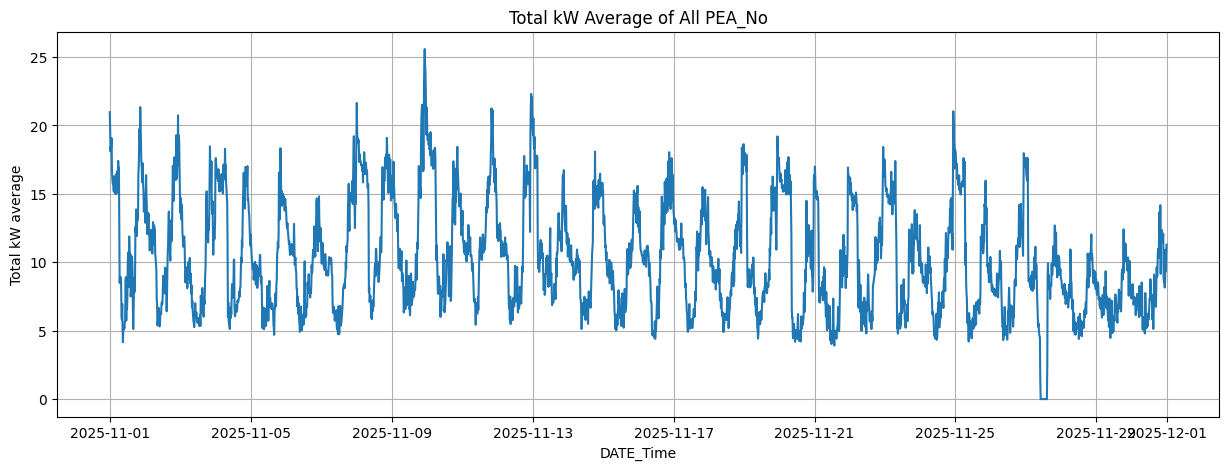

In [77]:
plt.figure(figsize=(15,5))
plt.plot(df_plot['DATE_Time'], df_plot['kW average'])
plt.xlabel('DATE_Time')
plt.ylabel('Total kW average')
plt.title('Total kW Average of All PEA_No')
plt.grid(True)
plt.show()

In [78]:
output_path = "E:/Documents/dtms69/LP_nov2026.parquet"

In [79]:
df2.to_parquet(output_path, engine='pyarrow', index=False)